Cell 1 — Imports

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
tf.random.set_seed(42)

Cell 2 — Generate Synthetic 3-Variable Nonlinear Dataset

We define a nonlinear function with 3 variables:
y=sin(x1​)+x22​+log(x32​+1)

In [2]:
# Generate synthetic dataset
N = 1000

x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-2, 2, N)
x3 = np.random.uniform(-2, 2, N)

X = np.stack([x1, x2, x3], axis=1)

# Nonlinear function
y = np.sin(x1) + x2**2 + np.log(x3**2 + 1)
y = y.reshape(-1, 1)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (1000, 3)
Output shape: (1000, 1)


Cell 3 — Define 3-Layer Neural Network Parameters

Architecture:

Input: 3

Hidden Layer 1: 64 neurons (ReLU)

Hidden Layer 2: 32 neurons (Tanh)

Output: 1 neuron (linear)

In [3]:
input_dim = 3
h1 = 64
h2 = 32
output_dim = 1

# Initialize weights
W1 = tf.Variable(tf.random.normal([input_dim, h1], stddev=0.1))
b1 = tf.Variable(tf.zeros([h1]))

W2 = tf.Variable(tf.random.normal([h1, h2], stddev=0.1))
b2 = tf.Variable(tf.zeros([h2]))

W3 = tf.Variable(tf.random.normal([h2, output_dim], stddev=0.1))
b3 = tf.Variable(tf.zeros([output_dim]))

learning_rate = 0.001

Cell 4 — Forward Pass (Using tf.einsum)

In [4]:
def forward(X):
    # Layer 1
    z1 = tf.einsum('bi,ij->bj', X, W1) + b1
    a1 = tf.nn.relu(z1)

    # Layer 2
    z2 = tf.einsum('bi,ij->bj', a1, W2) + b2
    a2 = tf.nn.tanh(z2)

    # Output layer
    z3 = tf.einsum('bi,ij->bj', a2, W3) + b3

    return z1, a1, z2, a2, z3

Cell 5 — Manual Backpropagation with Chain Rule

In [5]:
def compute_loss(y_pred, y_true):
    return tf.reduce_mean((y_pred - y_true)**2)

def backward(X, y_true):
    with tf.GradientTape(persistent=True) as tape:
        z1, a1, z2, a2, y_pred = forward(X)
        loss = compute_loss(y_pred, y_true)

    # Gradients
    dW3 = tape.gradient(loss, W3)
    db3 = tape.gradient(loss, b3)

    dW2 = tape.gradient(loss, W2)
    db2 = tape.gradient(loss, b2)

    dW1 = tape.gradient(loss, W1)
    db1 = tape.gradient(loss, b1)

    return loss, dW1, db1, dW2, db2, dW3, db3

Cell 6 — Training Loop

In [6]:
X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
y_tf = tf.convert_to_tensor(y, dtype=tf.float32)

epochs = 500
losses = []

for epoch in range(epochs):
    loss, dW1, db1, dW2, db2, dW3, db3 = backward(X_tf, y_tf)

    # Update weights manually
    W1.assign_sub(learning_rate * dW1)
    b1.assign_sub(learning_rate * db1)

    W2.assign_sub(learning_rate * dW2)
    b2.assign_sub(learning_rate * db2)

    W3.assign_sub(learning_rate * dW3)
    b3.assign_sub(learning_rate * db3)

    losses.append(loss.numpy())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.6f}")

Epoch 0, Loss: 6.457023
Epoch 50, Loss: 5.102009
Epoch 100, Loss: 4.046067
Epoch 150, Loss: 3.206205
Epoch 200, Loss: 2.572819
Epoch 250, Loss: 2.138005
Epoch 300, Loss: 1.866766
Epoch 350, Loss: 1.707164
Epoch 400, Loss: 1.611813
Epoch 450, Loss: 1.549194


Cell 7 — Plot Training Loss

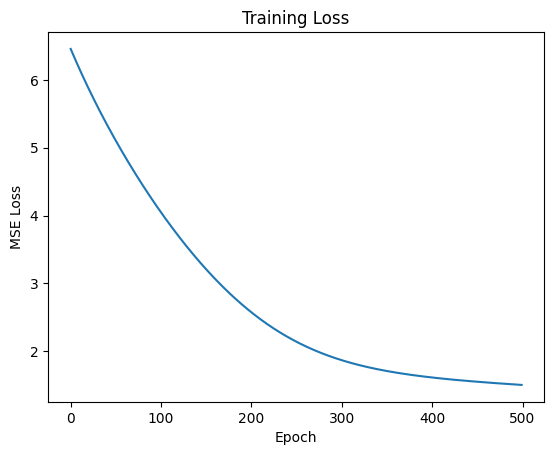

In [7]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

Cell 8 — Final Predictions

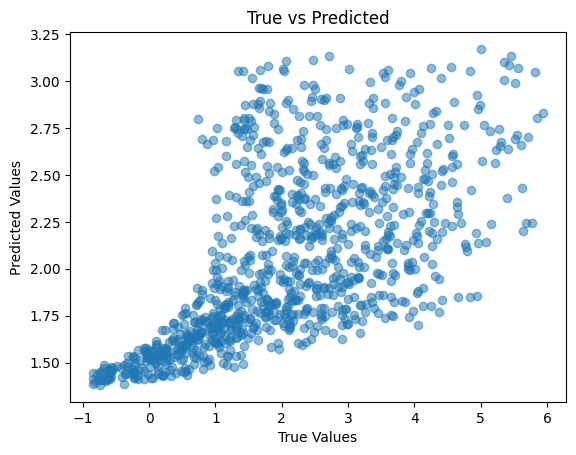

In [8]:
_, _, _, _, predictions = forward(X_tf)

plt.scatter(y, predictions.numpy(), alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted")
plt.show()

Cell 9 — 4D Visualization (3 inputs + output)

We reduce 3D inputs into 2D using PCA.

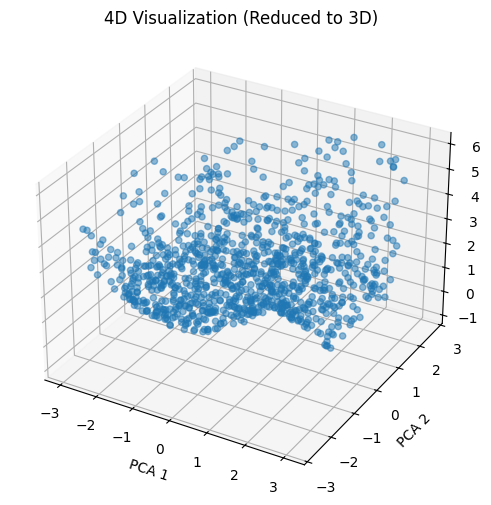

In [9]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_reduced[:,0], X_reduced[:,1], y.flatten(), alpha=0.5)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("Output")
plt.title("4D Visualization (Reduced to 3D)")
plt.show()